# Exploración de Dispersión de Precios

Este notebook evalúa la dispersión del precio unitario a nivel de `cliente padre` por `Mes`, `Marca`, `Familia` y `Zona`, con métricas robustas y ponderadas por volumen.

## 1. Configuración y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.options.display.float_format = '{:,.2f}'.format
from IPython.display import display

In [2]:
PATH_DATOS = 'datos/BBDD Ventas 25 - 26.xlsx'

# Opcional: activar filtro de marcas
USAR_FILTRO_MARCAS = False
MARCAS_FILTRO = ['LA PREFERIDA', 'SAN JORGE', 'WINTER']

# Parámetros del análisis robusto
WINSOR_P_LOW = 0.01
WINSOR_P_HIGH = 0.98
MIN_OBS_RANK = 8
MIN_MESES_TEMPORAL = 3

In [3]:
df_raw = pd.read_excel(PATH_DATOS, header=1)
columnas = [col for col in df_raw.columns if 'Unnamed' not in str(col)]

print(f'Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]:,}')
print(f'Columnas útiles detectadas: {len(columnas)}')

Filas: 434,066 | Columnas: 44
Columnas útiles detectadas: 43


## 2. Selección y Preparación de Variables

In [4]:
columnas_importantes = [
    'Mes',
    'SKU', 'Descripción', 'MARCA', 'FAMILIA HANA', 'TIPO CARNE',
    'CANAL HANA', 'ZONAL HANA', 'COD. CLIENTE PADRE',
    'KILOS',
    'VENTAS'
]

df_modelo = df_raw[columnas_importantes].copy()
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 434066 entries, 0 to 434065
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Mes                 434066 non-null  object 
 1   SKU                 434066 non-null  int64  
 2   Descripción         434066 non-null  str    
 3   MARCA               434066 non-null  str    
 4   FAMILIA HANA        434066 non-null  str    
 5   TIPO CARNE          433952 non-null  str    
 6   CANAL HANA          434066 non-null  str    
 7   ZONAL HANA          434066 non-null  str    
 8   COD. CLIENTE PADRE  282820 non-null  float64
 9   KILOS               434066 non-null  float64
 10  VENTAS              434066 non-null  int64  
dtypes: float64(2), int64(2), object(1), str(6)
memory usage: 36.4+ MB


In [5]:
# Normalizar Mes: mezcla de datetime + serial de fecha Excel
mes_num = pd.to_numeric(df_modelo['Mes'], errors='coerce')
mask_excel = mes_num.notna()
mes_dt = pd.to_datetime(df_modelo['Mes'].where(~mask_excel), errors='coerce')
mes_dt.loc[mask_excel] = pd.to_datetime(mes_num.loc[mask_excel], unit='D', origin='1899-12-30')
df_modelo['Mes'] = mes_dt

# Estandarizar texto para evitar duplicados por formato
for col in ['MARCA', 'FAMILIA HANA', 'CANAL HANA', 'ZONAL HANA']:
    df_modelo[col] = df_modelo[col].astype(str).str.strip().str.upper()

# Cliente padre como entero nullable (preserva faltantes)
df_modelo['COD. CLIENTE PADRE'] = pd.to_numeric(df_modelo['COD. CLIENTE PADRE'], errors='coerce').astype('Int64')

# Mantener solo filas con mes válido
df_modelo = df_modelo.dropna(subset=['Mes']).copy()

# Filtrar para tener sólo filas con COD. CLIENTE PADRE no vacío
df_modelo = df_modelo.dropna(subset=['COD. CLIENTE PADRE']).copy()

if USAR_FILTRO_MARCAS:
    df_modelo = df_modelo[df_modelo['MARCA'].isin(MARCAS_FILTRO)].copy()

print(f'Filas tras limpieza: {df_modelo.shape[0]:,}')

Filas tras limpieza: 282,820


In [6]:
df_modelo.head()

,Mes,SKU,Descripción,MARCA,FAMILIA HANA,TIPO CARNE,CANAL HANA,ZONAL HANA,COD. CLIENTE PADRE,KILOS,VENTAS
3,2025-01-01,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,ARICA,1196346,34.55,164684
7,2025-01-01,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,CHILLAN,1205327,120.95,594246
11,2025-01-01,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,CONCEPCION,1010880,8.35,39793
12,2025-01-01,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,CONCEPCION,1013028,8.08,38507
13,2025-01-01,20,ARROLLADO LOMO CON AJI SJ,SAN JORGE,ARROLLADOS,CERDO,TR,CONCEPCION,91995,73.20,348844


## 3. Construcción de Dataset Analítico (Nivel Cliente Padre)

In [7]:
keys_nivel = ['Mes', 'MARCA', 'FAMILIA HANA', 'ZONAL HANA', 'COD. CLIENTE PADRE']

df_final = (
    df_modelo.groupby(keys_nivel, as_index=False, dropna=False)
    .agg(
        VENTAS=('VENTAS', 'sum'),
        KILOS_VENDIDOS=('KILOS', 'sum')
    )
)

df_final['Precio Unitario Promedio'] = np.where(
    df_final['KILOS_VENDIDOS'] > 0,
    df_final['VENTAS'] / df_final['KILOS_VENDIDOS'],
    np.nan
)

# Evitar divisiones inválidas
df_final = df_final[df_final['KILOS_VENDIDOS'] > 0].copy()

print(f'Observaciones analíticas: {df_final.shape[0]:,}')

Observaciones analíticas: 104,509


In [8]:
df_final.head()

,Mes,MARCA,FAMILIA HANA,ZONAL HANA,COD. CLIENTE PADRE,VENTAS,KILOS_VENDIDOS,Precio Unitario Promedio
0,2025-01-01,LA PREFERIDA,ARROLLADOS,ANTOFAGASTA,62332,224993,30.86,"7,291.95"
1,2025-01-01,LA PREFERIDA,ARROLLADOS,CHILLAN,1205327,101013,15.03,"6,723.00"
2,2025-01-01,LA PREFERIDA,ARROLLADOS,CONCEPCION,60977,108213,14.84,"7,291.98"
3,2025-01-01,LA PREFERIDA,ARROLLADOS,CONCEPCION,62332,68691,9.42,"7,292.04"
4,2025-01-01,LA PREFERIDA,ARROLLADOS,CONCEPCION,1095609,11996,1.80,"6,645.98"


## 4. Winsorización y Helpers de Métricas

In [9]:
winsor_group = ['ZONAL HANA', 'MARCA', 'FAMILIA HANA']

def weighted_mean(values, weights):
    v = np.asarray(values, dtype=float)
    w = np.asarray(weights, dtype=float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    return np.average(v[m], weights=w[m])

def weighted_std(values, weights):
    v = np.asarray(values, dtype=float)
    w = np.asarray(weights, dtype=float)
    m = np.isfinite(v) & np.isfinite(w) & (w > 0)
    if m.sum() == 0:
        return np.nan
    v = v[m]
    w = w[m]
    mu = np.average(v, weights=w)
    return np.sqrt(np.average((v - mu) ** 2, weights=w))

def iqr(values):
    s = pd.Series(values).dropna()
    if s.empty:
        return np.nan
    return s.quantile(0.75) - s.quantile(0.25)

def mad(values):
    s = pd.Series(values).dropna()
    if s.empty:
        return np.nan
    med = s.median()
    return np.median(np.abs(s - med))

In [10]:
df_winsor = df_final.copy()

df_winsor['p_low'] = df_winsor.groupby(winsor_group)['Precio Unitario Promedio'].transform(
    lambda s: s.quantile(WINSOR_P_LOW)
)
df_winsor['p_high'] = df_winsor.groupby(winsor_group)['Precio Unitario Promedio'].transform(
    lambda s: s.quantile(WINSOR_P_HIGH)
)
df_winsor['Precio Unitario Winsor'] = df_winsor['Precio Unitario Promedio'].clip(
    lower=df_winsor['p_low'],
    upper=df_winsor['p_high']
)

print(f'Observaciones tras winsorización: {df_winsor.shape[0]:,}')

Observaciones tras winsorización: 104,509


## 5. Dispersión Global Robusta (Zona-Marca-Familia)

In [11]:
def agg_dispersion_global(g):
    p = g['Precio Unitario Winsor']
    w = g['KILOS_VENDIDOS']
    return pd.Series({
        'n_observaciones': p.count(),
        'mean_w': weighted_mean(p, w),
        'std_w': weighted_std(p, w),
        'mediana': p.median(),
        'iqr': iqr(p),
        'mad': mad(p)
    })

dispersion_precio = (
    df_winsor.groupby(['ZONAL HANA', 'MARCA', 'FAMILIA HANA'], as_index=False)
    .apply(agg_dispersion_global, include_groups=False)
    .reset_index()
)
if 'level_3' in dispersion_precio.columns:
    dispersion_precio = dispersion_precio.drop(columns=['level_3'])

dispersion_precio = dispersion_precio[dispersion_precio['n_observaciones'] >= MIN_OBS_RANK].copy()
dispersion_precio = dispersion_precio.sort_values(['std_w', 'n_observaciones'], ascending=[False, False])

print('Top dispersión global robusta:')
dispersion_precio.head(20)

Top dispersión global robusta:


,index,ZONAL HANA,MARCA,FAMILIA HANA,n_observaciones,mean_w,std_w,mediana,iqr,mad
581,581,SANTIAGO,LA PREFERIDA,SECOS,245.00,"24,287.59","7,088.42","27,061.16","3,563.00","1,980.80"
216,216,COYHAIQUE,LA PREFERIDA,SNACKS,24.00,"15,139.04","4,615.71","21,632.85","16,846.16","8,107.06"
714,714,VIÑA DEL MAR,LA PREFERIDA,SECOS,90.00,"27,719.75","3,827.22","27,473.21","2,689.09","1,648.21"
434,434,PUNTA ARENAS,SAN JORGE,CARNES,16.00,"8,280.62","3,163.02","9,234.00",0.00,0.00
668,668,TEMUCO,LA PREFERIDA,SECOS,122.00,"27,439.30","2,646.15","27,867.52","3,513.39","1,470.87"
340,340,OSORNO,LA PREFERIDA,CARNES,88.00,"8,862.60","2,396.51","9,523.89","2,642.15","2,175.00"
660,660,TEMUCO,LA PREFERIDA,CARNES,115.00,"9,624.63","2,394.85","9,336.94","4,563.19","2,361.94"
276,276,LA SERENA,LA PREFERIDA,SECOS,79.00,"27,958.73","2,303.56","27,474.11","2,689.02","1,863.96"
630,630,TALCA,LA PREFERIDA,TOCINOS,244.00,"10,186.35","2,253.32","11,843.83","2,035.64",883.43
112,112,CHILLAN,LA PREFERIDA,TOCINOS,211.00,"10,275.04","2,253.18","11,742.30","1,861.33",968.41


## 6. Dispersión Intra-Mes (Entre Clientes Dentro de Cada Mes)

In [12]:
def agg_intra_mes(g):
    p = g['Precio Unitario Winsor']
    w = g['KILOS_VENDIDOS']
    return pd.Series({
        'n_obs_mes': p.count(),
        'std_w_intra_mes': weighted_std(p, w),
        'mediana_intra_mes': p.median(),
        'iqr_intra_mes': iqr(p),
        'mad_intra_mes': mad(p)
    })

dispersion_intra_mes_mensual = (
    df_winsor.groupby(['Mes', 'ZONAL HANA', 'MARCA', 'FAMILIA HANA'], as_index=False)
    .apply(agg_intra_mes, include_groups=False)
    .reset_index()
)
if 'level_4' in dispersion_intra_mes_mensual.columns:
    dispersion_intra_mes_mensual = dispersion_intra_mes_mensual.drop(columns=['level_4'])

dispersion_intra_mes = (
    dispersion_intra_mes_mensual.groupby(['ZONAL HANA', 'MARCA', 'FAMILIA HANA'], as_index=False)
    .agg(
        n_meses=('Mes', 'nunique'),
        n_obs_mes_prom=('n_obs_mes', 'mean'),
        std_w_intra_mes_prom=('std_w_intra_mes', 'mean'),
        std_w_intra_mes_mediana=('std_w_intra_mes', 'median'),
        iqr_intra_mes_prom=('iqr_intra_mes', 'mean'),
        iqr_intra_mes_mediana=('iqr_intra_mes', 'median'),
        mad_intra_mes_prom=('mad_intra_mes', 'mean'),
        mad_intra_mes_mediana=('mad_intra_mes', 'median')
    )
    .sort_values(['std_w_intra_mes_prom', 'n_meses'], ascending=[False, False])
)

print('Top dispersión intra-mes:')
dispersion_intra_mes.head(20)

Top dispersión intra-mes:


,ZONAL HANA,MARCA,FAMILIA HANA,n_meses,n_obs_mes_prom,std_w_intra_mes_prom,std_w_intra_mes_mediana,iqr_intra_mes_prom,iqr_intra_mes_mediana,mad_intra_mes_prom,mad_intra_mes_mediana
581,SANTIAGO,LA PREFERIDA,SECOS,14,17.50,"4,946.70","5,679.81","4,235.81","3,599.14","1,668.25","1,646.45"
216,COYHAIQUE,LA PREFERIDA,SNACKS,10,2.40,"3,138.06","3,698.18","6,026.87","8,477.62","2,918.37","3,460.77"
630,TALCA,LA PREFERIDA,TOCINOS,14,17.43,"2,218.25","2,217.19","1,907.74","1,878.86",901.07,958.35
153,CONCEPCION,LA PREFERIDA,TOCINOS,14,17.71,"2,188.78","2,177.36","3,057.65","3,099.80","1,388.20","1,375.21"
584,SANTIAGO,LA PREFERIDA,TOCINOS,14,80.00,"2,182.15","2,216.32","3,775.05","3,650.00","1,949.62","1,961.08"
112,CHILLAN,LA PREFERIDA,TOCINOS,14,15.07,"2,145.52","2,175.63","1,720.61","1,668.90",849.44,858.51
713,VIÑA DEL MAR,LA PREFERIDA,SALAMES,14,24.79,"2,090.67","2,080.92","4,210.54","4,275.74","1,054.02","1,084.85"
542,SAN FERNANDO,LA PREFERIDA,TOCINOS,14,17.21,"2,057.36","1,989.11","1,801.06","1,625.11",887.37,872.91
351,OSORNO,LA PREFERIDA,TOCINOS,14,14.64,"1,999.47","1,930.94","1,616.18","1,683.86",769.53,774.58
580,SANTIAGO,LA PREFERIDA,SALAMES,14,77.29,"1,986.83","1,970.65","2,374.15","2,341.79",713.05,780.27


## 7. Dispersión Temporal (Variación del Nivel de Precio Mes a Mes)

In [13]:
serie_mensual_grupo = (
    df_winsor.groupby(['Mes', 'ZONAL HANA', 'MARCA', 'FAMILIA HANA'], as_index=False)
    .apply(
        lambda g: pd.Series({
            'mean_w_mes': weighted_mean(g['Precio Unitario Winsor'], g['KILOS_VENDIDOS']),
            'kilos_mes': g['KILOS_VENDIDOS'].sum(),
            'n_obs_mes': g['Precio Unitario Winsor'].count()
        }),
        include_groups=False
    )
    .reset_index()
)
if 'level_4' in serie_mensual_grupo.columns:
    serie_mensual_grupo = serie_mensual_grupo.drop(columns=['level_4'])

dispersion_temporal = (
    serie_mensual_grupo.groupby(['ZONAL HANA', 'MARCA', 'FAMILIA HANA'], as_index=False)
    .agg(
        n_meses=('Mes', 'nunique'),
        std_temporal=('mean_w_mes', 'std'),
        mediana_temporal=('mean_w_mes', 'median'),
        iqr_temporal=('mean_w_mes', iqr),
        mad_temporal=('mean_w_mes', mad)
    )
    .query('n_meses >= @MIN_MESES_TEMPORAL')
    .sort_values(['std_temporal', 'n_meses'], ascending=[False, False])
)

print('Top dispersión temporal:')
dispersion_temporal.head(20)

Top dispersión temporal:


,ZONAL HANA,MARCA,FAMILIA HANA,n_meses,std_temporal,mediana_temporal,iqr_temporal,mad_temporal
581,SANTIAGO,LA PREFERIDA,SECOS,14,"3,843.03","25,483.04","6,478.10","3,430.75"
434,PUNTA ARENAS,SAN JORGE,CARNES,11,"2,646.35","9,234.00","1,470.04",0.00
13,ANTOFAGASTA,LOS NOGALES,QUESOS,3,"2,079.44","7,498.00","2,078.65","1,979.64"
306,LOS ANGELES,LA PREFERIDA,CARNES,14,"2,049.02","11,698.79","3,927.45",0.12
219,COYHAIQUE,LOS NOGALES,QUESOS,10,"1,977.84","10,411.29","3,790.57",854.71
451,RANCAGUA,LA PREFERIDA,CARNES,14,"1,946.67","11,137.25","3,745.56",385.43
619,TALCA,LA PREFERIDA,CARNES,14,"1,855.98","11,495.35","3,295.04",170.69
101,CHILLAN,LA PREFERIDA,CARNES,14,"1,805.34","11,087.90","3,319.75",288.35
382,PUERTO MONTT,LA PREFERIDA,CARNES,14,"1,763.96","9,744.89","3,409.97",434.63
668,TEMUCO,LA PREFERIDA,SECOS,14,"1,758.65","28,411.59","1,343.57",649.85


## 8. Validaciones y Comparación Antes/Después

In [14]:
# Integridad: winsorización no elimina filas
assert len(df_winsor) == len(df_final), 'df_winsor y df_final deben tener la misma cantidad de filas'

# Integridad: precio winsorizado siempre dentro de [p_low, p_high]
tol = 1e-9
ok_bounds = (
    (df_winsor['Precio Unitario Winsor'] >= (df_winsor['p_low'] - tol))
    & (df_winsor['Precio Unitario Winsor'] <= (df_winsor['p_high'] + tol))
).all()
assert ok_bounds, 'Hay precios winsorizados fuera de los límites del grupo'

# Métricas no negativas
for col in ['std_w', 'iqr', 'mad']:
    assert (dispersion_precio[col].dropna() >= 0).all(), f'{col} contiene valores negativos'
for col in ['std_temporal', 'iqr_temporal', 'mad_temporal']:
    assert (dispersion_temporal[col].dropna() >= 0).all(), f'{col} contiene valores negativos'

# Consistencia de n_observaciones
real_counts = (
    df_winsor.groupby(['ZONAL HANA', 'MARCA', 'FAMILIA HANA'])['Precio Unitario Winsor']
    .count()
    .rename('n_real')
    .reset_index()
)
chk = dispersion_precio.merge(real_counts, on=['ZONAL HANA', 'MARCA', 'FAMILIA HANA'], how='left')
assert (chk['n_observaciones'] == chk['n_real']).all(), 'n_observaciones no coincide con conteo real'

# Restricciones mínimas
assert (dispersion_precio['n_observaciones'] >= MIN_OBS_RANK).all(), 'Hay grupos en dispersion_precio con n_observaciones bajo el mínimo'
assert (dispersion_temporal['n_meses'] >= MIN_MESES_TEMPORAL).all(), 'Hay grupos en dispersion_temporal con n_meses bajo el mínimo'

print('Validaciones OK')

# Comparación funcional: top-10 baseline (Q1-Q3 global) vs robusto
q1_base = df_final['Precio Unitario Promedio'].quantile(0.25)
q3_base = df_final['Precio Unitario Promedio'].quantile(0.75)
baseline_q13 = (
    df_final[df_final['Precio Unitario Promedio'].between(q1_base, q3_base)]
    .groupby(['ZONAL HANA', 'MARCA', 'FAMILIA HANA'], as_index=False)
    .agg(
        std_baseline=('Precio Unitario Promedio', 'std'),
        n_obs_baseline=('Precio Unitario Promedio', 'count')
    )
    .query('n_obs_baseline >= @MIN_OBS_RANK')
    .sort_values(['std_baseline', 'n_obs_baseline'], ascending=[False, False])
)

top10_baseline = baseline_q13[['ZONAL HANA', 'MARCA', 'FAMILIA HANA', 'std_baseline', 'n_obs_baseline']].head(10)
top10_robusto = dispersion_precio[['ZONAL HANA', 'MARCA', 'FAMILIA HANA', 'std_w', 'n_observaciones']].head(10)

print('Top-10 baseline (Q1-Q3 global):')
display(top10_baseline)
print('Top-10 robusto (winsor + std ponderada):')
display(top10_robusto)

Validaciones OK
Top-10 baseline (Q1-Q3 global):


,ZONAL HANA,MARCA,FAMILIA HANA,std_baseline,n_obs_baseline
383,RANCAGUA,SAN JORGE,SALAMES,"1,325.43",12
206,LA SERENA,LA PREFERIDA,JAMON G1,"1,314.75",22
217,LA SERENA,LOS NOGALES,QUESOS,"1,228.12",8
471,SANTIAGO,LOS NOGALES,QUESOS,"1,101.83",90
500,TALCA,LA PREFERIDA,CARNES,"1,081.31",9
358,RANCAGUA,LA PREFERIDA,CARNES,989.23,12
301,PUERTO MONTT,LA PREFERIDA,CARNES,972.47,14
458,SANTIAGO,LA PREFERIDA,CARNES,951.95,45
470,SANTIAGO,LOS NOGALES,LACTEOS,941.30,37
343,PUNTA ARENAS,SAN JORGE,FIAMBRES,862.98,53


Top-10 robusto (winsor + std ponderada):


,ZONAL HANA,MARCA,FAMILIA HANA,std_w,n_observaciones
581,SANTIAGO,LA PREFERIDA,SECOS,"7,088.42",245.00
216,COYHAIQUE,LA PREFERIDA,SNACKS,"4,615.71",24.00
714,VIÑA DEL MAR,LA PREFERIDA,SECOS,"3,827.22",90.00
434,PUNTA ARENAS,SAN JORGE,CARNES,"3,163.02",16.00
668,TEMUCO,LA PREFERIDA,SECOS,"2,646.15",122.00
340,OSORNO,LA PREFERIDA,CARNES,"2,396.51",88.00
660,TEMUCO,LA PREFERIDA,CARNES,"2,394.85",115.00
276,LA SERENA,LA PREFERIDA,SECOS,"2,303.56",79.00
630,TALCA,LA PREFERIDA,TOCINOS,"2,253.32",244.00
112,CHILLAN,LA PREFERIDA,TOCINOS,"2,253.18",211.00


## 9. Visualizaciones

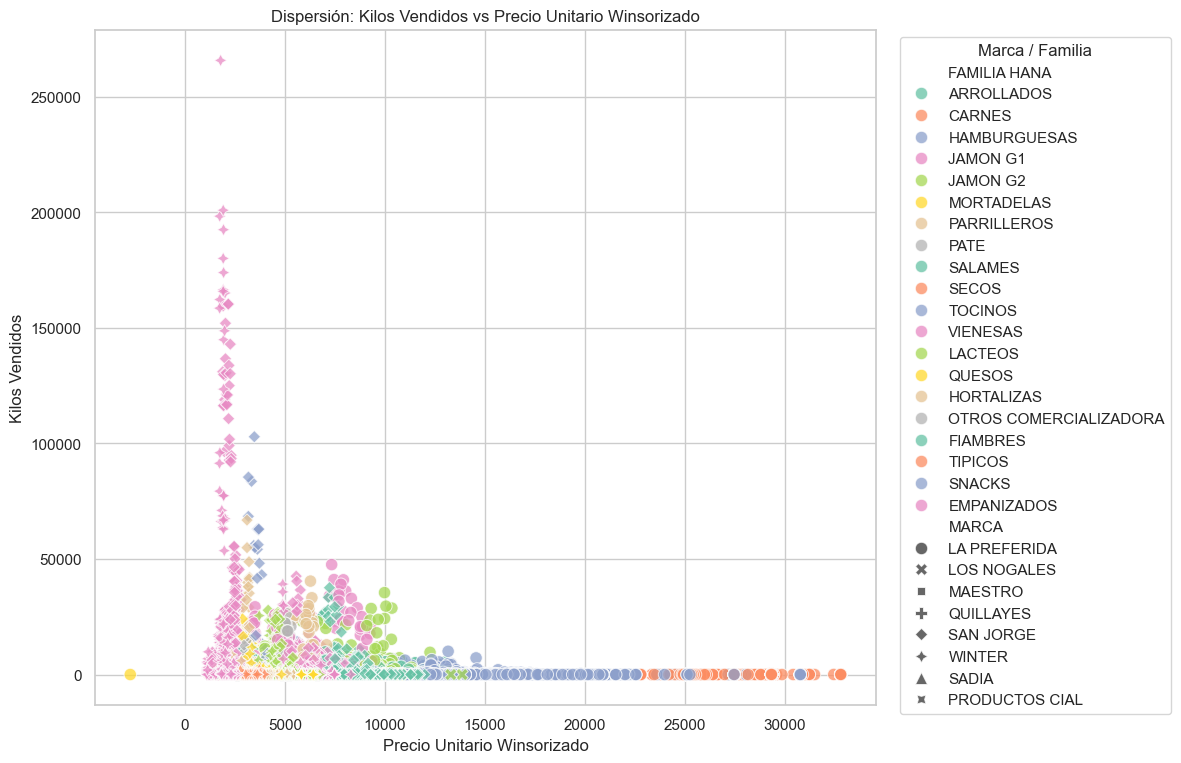

In [15]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_winsor,
    x='Precio Unitario Winsor',
    y='KILOS_VENDIDOS',
    hue='FAMILIA HANA',
    style='MARCA',
    palette='Set2',
    s=80,
    alpha=0.75
)
plt.title('Dispersión: Kilos Vendidos vs Precio Unitario Winsorizado')
plt.xlabel('Precio Unitario Winsorizado')
plt.ylabel('Kilos Vendidos')
plt.legend(title='Marca / Familia', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

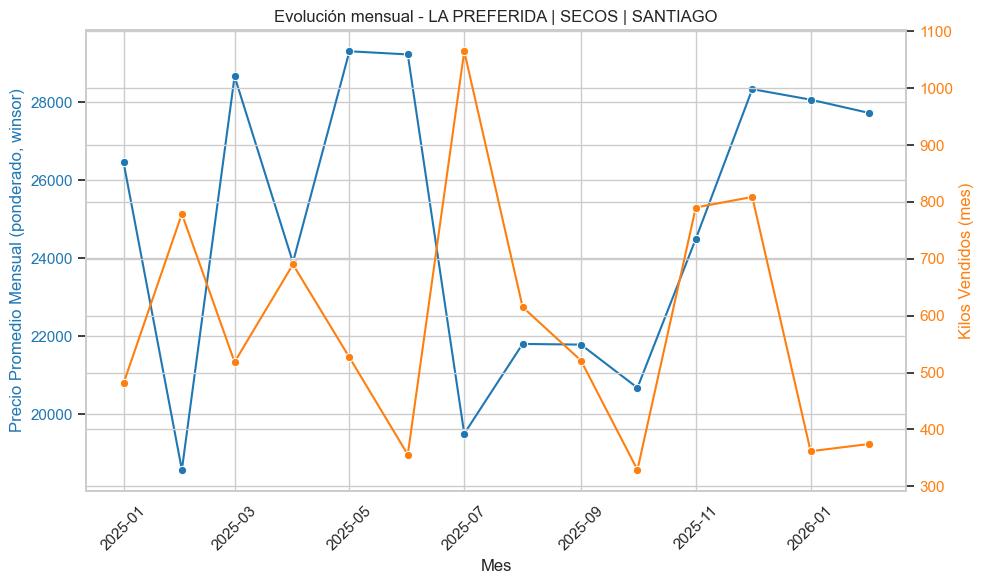

In [16]:
# Ajusta estos parámetros para explorar otro segmento
MARCA_OBJ = 'LA PREFERIDA'
FAMILIA_OBJ = 'SECOS'
ZONA_OBJ = 'SANTIAGO'

filtro_grafico = (
    (serie_mensual_grupo['MARCA'] == MARCA_OBJ)
    & (serie_mensual_grupo['FAMILIA HANA'] == FAMILIA_OBJ)
    & (serie_mensual_grupo['ZONAL HANA'] == ZONA_OBJ)
)
datos_grafico = serie_mensual_grupo[filtro_grafico].sort_values('Mes')

if datos_grafico.empty:
    print('No hay datos para el segmento seleccionado.')
else:
    fig, ax1 = plt.subplots(figsize=(10, 6))

    sns.lineplot(
        data=datos_grafico,
        x='Mes',
        y='mean_w_mes',
        marker='o',
        ax=ax1,
        color='tab:blue'
    )
    ax1.set_ylabel('Precio Promedio Mensual (ponderado, winsor)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    sns.lineplot(
        data=datos_grafico,
        x='Mes',
        y='kilos_mes',
        marker='o',
        ax=ax2,
        color='tab:orange'
    )
    ax2.set_ylabel('Kilos Vendidos (mes)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    ax1.set_title(f'Evolución mensual - {MARCA_OBJ} | {FAMILIA_OBJ} | {ZONA_OBJ}')
    ax1.set_xlabel('Mes')
    ax1.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    plt.show()